# Vendor matchid quality classification

## Objective

Classify each vendor matchid using multiple, explainable quality metrics. The intended output grain is one row per `(day, vendor, matchid)`, containing metric values, quality flags, and a final quality class.

Candidate metric families include:

- **Membership size:** distinct UID and household counts.
- **Stability:** stable UID count and share.
- **External identity consistency:** distinct NPI hashes supported by unambiguous UIDs.
- **External evidence quality:** NPI-linked UID coverage and ambiguous-UID share.

Final classifications should preserve metric-level reasons instead of relying only on one opaque score. Thresholds should be calibrated per vendor because vendor populations and graph-building behavior may differ.

## Current scope

This notebook currently develops the NPI-based metrics using a 5% Liveramp membership sample for **2026-09-28**. `iceberg.health.npiiddaily` provides an external identity signal. NPI evidence is incomplete and may itself be ambiguous, so the first step validates that signal before applying it at matchid level.


In [10]:
from __future__ import annotations

import importlib
import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LogNorm

pd.set_option('display.float_format', lambda x: '%.3f' % x)

SOURCE_DAY = date.fromisoformat('2026-09-28')

In [11]:
def run_query(sql: str) -> pd.DataFrame:
    config_dir = Path.home() / '.pulsepoint'
    sys.path.insert(0, str(config_dir))

    from dotenv import load_dotenv

    load_dotenv(config_dir / '.env', override=False)
    dbfuncs = importlib.import_module('dbfuncs')
    return dbfuncs.query2df(sql, print_time=True)

## Baseline Vendor population

Establish row, matchid, and distinct-cookie counts before joining external identity data. Comparing rows with distinct UIDs also reveals repeated cookies within the sample.

In [12]:
run_query("""
select 
    count(*) as n_rows, 
    count(distinct matchid) as n_matchids, 
    count(distinct uid) as n_uids 
from iceberg.jteixeira_ipa.nscreen_membership_sample_liveramp_20260928_line_filter_v1_5pct""")

Query executed in 5.692 seconds


,n_rows,n_matchids,n_uids
0,155587782,7720131,154336770


In [13]:
run_query("""
select 
    count(*) as n_rows, 
    count(distinct matchid) as n_matchids, 
    count(distinct uid) as n_uids 
from iceberg.jteixeira_ipa.nscreen_membership_sample_throtle_20260928_line_filter_v1_5pct""")

Query executed in 6.012 seconds


,n_rows,n_matchids,n_uids
0,16576277,3318058,16569149


In [14]:
run_query("""
select 
    count(*) as n_rows, 
    count(distinct matchid) as n_matchids, 
    count(distinct uid) as n_uids 
from iceberg.jteixeira_ipa.nscreen_membership_sample_experian_20260928_line_filter_v1_5pct""")

Query executed in 5.342 seconds


,n_rows,n_matchids,n_uids
0,66167108,3942584,66167108


## NPI-source ambiguity

Measure how often `npiiddaily` assigns multiple distinct NPI hashes to one userid on the selected day. This source-wide check establishes whether NPI mappings are unique enough for matchid validation.

In [15]:
provider_npi_summary = run_query("""
WITH user_npi_counts AS (
    SELECT
        provider,
        userid,
        COUNT(DISTINCT npisha256) AS n_npi
    FROM iceberg.health.npiiddaily
    WHERE day = '2026-09-28'
      AND userid IS NOT NULL
      AND npisha256 IS NOT NULL
    GROUP BY
        provider,
        userid
)
SELECT
    provider,
    COUNT(*) AS n_cookies,
    COUNT_IF(n_npi > 1) AS n_cookies_multiple_npi,
    COUNT_IF(n_npi = 1) AS n_cookies_single_npi,
    CAST(COUNT_IF(n_npi > 1) AS DOUBLE)
        / NULLIF(COUNT(*), 0) AS ratio_multiple_npi
FROM user_npi_counts
GROUP BY provider
ORDER BY ratio_multiple_npi DESC
""")

provider_npi_summary

Query executed in 8.372 seconds


,provider,n_cookies,n_cookies_multiple_npi,n_cookies_single_npi,ratio_multiple_npi
0,DMD,59168003,8093458,51074545,0.137
1,TH,141776830,13606492,128170338,0.096
2,LI,44685602,2645476,42040126,0.059
3,MDSC,5862,3,5859,0.001
4,IQ,7446261,5,7446256,0.000
5,MATS,1991752,0,1991752,0.000


### Source-wide finding

On 2026-09-28, `npiiddaily` contains 143,654,464 userids with at least one NPI hash. Among them, 14,077,789 (approximately 9.8%) map to multiple distinct NPI hashes. This rate describes the full NPI source, not the vendor-overlapping population.

## Raw Vendor-to-NPI join

In [16]:
run_query("""
with joined_data as (
select lr.*, npiid.npisha256 from iceberg.jteixeira_ipa.nscreen_membership_sample_liveramp_20260928_line_filter_v1_5pct as lr
left join iceberg.health.npiiddaily npiid
on lr.uid=npiid.userid and npiid.day = '2026-09-28')
select count(*) from joined_data
""")

Query executed in 7.404 seconds


,_col0
0,158707587


### Join result

The raw join produces 95,089,245 rows versus 93,209,199 Liveramp rows, an increase of 1,880,046 rows. This increase indicates one-to-many matches on `userid`; it does not indicate additional cookies.

In [17]:
run_query("""
WITH lr_uids AS (
    SELECT DISTINCT uid
    FROM iceberg.jteixeira_ipa.nscreen_membership_sample_liveramp_20260928_line_filter_v1_5pct
    WHERE uid IS NOT NULL
),
npi_counts AS (
    SELECT
        userid,
        COUNT(DISTINCT npisha256) AS n_npis
    FROM iceberg.health.npiiddaily
    WHERE day = '2026-09-28'
      AND userid IS NOT NULL
      AND npisha256 IS NOT NULL
    GROUP BY userid
),
classified AS (
    SELECT
        lr.uid,
        COALESCE(npi.n_npis, 0) AS n_npis
    FROM lr_uids lr
    LEFT JOIN npi_counts npi
        ON lr.uid = npi.userid
)
SELECT
    COUNT(*) AS n_cookies,
    COUNT_IF(n_npis = 0) AS n_cookies_zero_npi,
    COUNT_IF(n_npis = 1) AS n_cookies_one_npi,
    COUNT_IF(n_npis > 1) AS n_cookies_multiple_npis,
    CAST(COUNT_IF(n_npis = 0) AS DOUBLE)
        / NULLIF(COUNT(*), 0) AS ratio_zero_npi,
    CAST(COUNT_IF(n_npis = 1) AS DOUBLE)
        / NULLIF(COUNT(*), 0) AS ratio_one_npi,
    CAST(COUNT_IF(n_npis > 1) AS DOUBLE)
        / NULLIF(COUNT(*), 0) AS ratio_multiple_npis
FROM classified
""")

Query executed in 9.441 seconds


,n_cookies,n_cookies_zero_npi,n_cookies_one_npi,n_cookies_multiple_npis,ratio_zero_npi,ratio_one_npi,ratio_multiple_npis
0,154336770,151207085,2799402,330283,0.980,0.018,0.002


98.0% of cookies provded by **liveramp** do not map to any npi, 1.8% map to a single npi, 0.2% map to multiple npis

In [18]:
run_query("""
WITH th_uids AS (
    SELECT DISTINCT uid
    FROM iceberg.jteixeira_ipa.nscreen_membership_sample_throtle_20260928_line_filter_v1_5pct
    WHERE uid IS NOT NULL
),
npi_counts AS (
    SELECT
        userid,
        COUNT(DISTINCT npisha256) AS n_npis
    FROM iceberg.health.npiiddaily
    WHERE day = '2026-09-28'
      AND userid IS NOT NULL
      AND npisha256 IS NOT NULL
    GROUP BY userid
),
classified AS (
    SELECT
        th.uid,
        COALESCE(npi.n_npis, 0) AS n_npis
    FROM th_uids th
    LEFT JOIN npi_counts npi
        ON th.uid = npi.userid
)
SELECT
    COUNT(*) AS n_cookies,
    COUNT_IF(n_npis = 0) AS n_cookies_zero_npi,
    COUNT_IF(n_npis = 1) AS n_cookies_one_npi,
    COUNT_IF(n_npis > 1) AS n_cookies_multiple_npis,
    CAST(COUNT_IF(n_npis = 0) AS DOUBLE)
        / NULLIF(COUNT(*), 0) AS ratio_zero_npi,
    CAST(COUNT_IF(n_npis = 1) AS DOUBLE)
        / NULLIF(COUNT(*), 0) AS ratio_one_npi,
    CAST(COUNT_IF(n_npis > 1) AS DOUBLE)
        / NULLIF(COUNT(*), 0) AS ratio_multiple_npis
FROM classified
""")

Query executed in 12.622 seconds


,n_cookies,n_cookies_zero_npi,n_cookies_one_npi,n_cookies_multiple_npis,ratio_zero_npi,ratio_one_npi,ratio_multiple_npis
0,16569149,15354246,1044152,170751,0.927,0.063,0.010


92.7% of cookies provded by **throtle** do not map to any npi, 6.3% map to a single npi, 1.0% map to multiple npis

In [19]:
run_query("""
WITH ex_uids AS (
    SELECT DISTINCT uid
    FROM iceberg.jteixeira_ipa.nscreen_membership_sample_experian_20260928_line_filter_v1_5pct
    WHERE uid IS NOT NULL
),
npi_counts AS (
    SELECT
        userid,
        COUNT(DISTINCT npisha256) AS n_npis
    FROM iceberg.health.npiiddaily
    WHERE day = '2026-09-28'
      AND userid IS NOT NULL
      AND npisha256 IS NOT NULL
    GROUP BY userid
),
classified AS (
    SELECT
        ex.uid,
        COALESCE(npi.n_npis, 0) AS n_npis
    FROM ex_uids ex
    LEFT JOIN npi_counts npi
        ON ex.uid = npi.userid
)
SELECT
    COUNT(*) AS n_cookies,
    COUNT_IF(n_npis = 0) AS n_cookies_zero_npi,
    COUNT_IF(n_npis = 1) AS n_cookies_one_npi,
    COUNT_IF(n_npis > 1) AS n_cookies_multiple_npis,
    CAST(COUNT_IF(n_npis = 0) AS DOUBLE)
        / NULLIF(COUNT(*), 0) AS ratio_zero_npi,
    CAST(COUNT_IF(n_npis = 1) AS DOUBLE)
        / NULLIF(COUNT(*), 0) AS ratio_one_npi,
    CAST(COUNT_IF(n_npis > 1) AS DOUBLE)
        / NULLIF(COUNT(*), 0) AS ratio_multiple_npis
FROM classified
""")

Query executed in 8.143 seconds


,n_cookies,n_cookies_zero_npi,n_cookies_one_npi,n_cookies_multiple_npis,ratio_zero_npi,ratio_one_npi,ratio_multiple_npis
0,66167108,65687051,433287,46770,0.993,0.007,0.001


99.3% of cookies provded by **experian** do not map to any npi, 0.7% map to a single npi, 0.1% map to multiple npis

## Matchid-level NPI quality metrics

Each mapped UID contributes one total support vote, divided evenly across its distinct NPIs. This fractional support lets an ambiguous UID contribute to a shared NPI without giving every candidate a full vote.

- `n_distinct_npis`: distinct NPI candidates linked to the matchid.
- `dominant_npi_weighted_support`: largest fractional UID support received by one NPI.
- `npi_purity`: dominant weighted support divided by UIDs having any NPI evidence.
- `npi_quality_score`: category-only score using single-, zero-, and multiple-NPI UID counts.
- `npi_coherent_quality_score`: dominant support minus zero- and multiple-NPI penalties, divided by total UIDs.

$$
\text{coherent score} =
\frac{
    \text{dominant weighted support}
    - \gamma n_0
    - \lambda n_{>1}
}{
    n_{\text{uids}}
}
$$

Defaults use $\gamma=0.25$ for zero-NPI UIDs and $\lambda=1.0$ for multiple-NPI UIDs. Raw counts and ratios remain available for interpretation.

In [20]:
matchid_npi_quality = run_query("""WITH params AS (
    SELECT
        CAST(0.25 AS DOUBLE) AS zero_npi_penalty,
        CAST(1.0 AS DOUBLE) AS multiple_npi_penalty
),

vendor_uids AS (
    SELECT DISTINCT
        'liveramp' AS vendor,
        matchid,
        uid
    FROM iceberg.jteixeira_ipa
        .nscreen_membership_sample_liveramp_20260928_line_filter_v1_5pct
    WHERE matchid IS NOT NULL
      AND uid IS NOT NULL

    UNION ALL

    SELECT DISTINCT
        'throtle' AS vendor,
        matchid,
        uid
    FROM iceberg.jteixeira_ipa
        .nscreen_membership_sample_throtle_20260928_line_filter_v1_5pct
    WHERE matchid IS NOT NULL
      AND uid IS NOT NULL

    UNION ALL

    SELECT DISTINCT
        'experian' AS vendor,
        matchid,
        uid
    FROM iceberg.jteixeira_ipa
        .nscreen_membership_sample_experian_20260928_line_filter_v1_5pct
    WHERE matchid IS NOT NULL
      AND uid IS NOT NULL
),

npi_mappings AS (
    SELECT DISTINCT
        userid,
        npisha256
    FROM iceberg.health.npiiddaily
    WHERE day = '2026-09-28'
      AND userid IS NOT NULL
      AND npisha256 IS NOT NULL
),

uid_npi_candidates AS (
    SELECT
        vendor.vendor,
        vendor.matchid,
        vendor.uid,
        npi.npisha256
    FROM vendor_uids vendor
    LEFT JOIN npi_mappings npi
        ON vendor.uid = npi.userid
),

classified_candidates AS (
    SELECT
        vendor,
        matchid,
        uid,
        npisha256,
        COUNT(npisha256) OVER (
            PARTITION BY vendor, matchid, uid
        ) AS n_npis,
        ROW_NUMBER() OVER (
            PARTITION BY vendor, matchid, uid
            ORDER BY npisha256
        ) AS uid_row_number
    FROM uid_npi_candidates
),

grouped_metrics AS (
    SELECT
        vendor,
        matchid,
        npisha256,
        GROUPING(npisha256) AS is_matchid_rollup,
        COUNT_IF(uid_row_number = 1) AS n_uids,
        COUNT_IF(
            uid_row_number = 1 AND n_npis = 0
        ) AS n_uids_zero_npi,
        COUNT_IF(
            uid_row_number = 1 AND n_npis = 1
        ) AS n_uids_one_npi,
        COUNT_IF(
            uid_row_number = 1 AND n_npis > 1
        ) AS n_uids_multiple_npis,
        SUM(
            CASE
                WHEN npisha256 IS NOT NULL
                    THEN CAST(1.0 AS DOUBLE) / n_npis
                ELSE CAST(0.0 AS DOUBLE)
            END
        ) AS weighted_uid_support
    FROM classified_candidates
    GROUP BY GROUPING SETS (
        (vendor, matchid),
        (vendor, matchid, npisha256)
    )
),

matchid_metrics AS (
    SELECT
        grouped.*,
        SUM(
            CASE
                WHEN is_matchid_rollup = 0
                 AND npisha256 IS NOT NULL
                    THEN 1
                ELSE 0
            END
        ) OVER (
            PARTITION BY vendor, matchid
        ) AS n_distinct_npis,
        MAX(
            CASE
                WHEN is_matchid_rollup = 0
                 AND npisha256 IS NOT NULL
                    THEN weighted_uid_support
            END
        ) OVER (
            PARTITION BY vendor, matchid
        ) AS dominant_npi_weighted_support
    FROM grouped_metrics grouped
)

SELECT
    vendor,
    matchid,
    n_uids,
    n_uids_zero_npi,
    n_uids_one_npi,
    n_uids_multiple_npis,
    n_uids_one_npi + n_uids_multiple_npis AS n_uids_with_npi,
    n_distinct_npis,
    COALESCE(
        dominant_npi_weighted_support,
        0.0
    ) AS dominant_npi_weighted_support,
    dominant_npi_weighted_support
        / NULLIF(
            n_uids_one_npi + n_uids_multiple_npis,
            0
        ) AS npi_purity,
    CAST(n_uids_zero_npi AS DOUBLE)
        / NULLIF(n_uids, 0) AS ratio_zero_npi,
    CAST(n_uids_one_npi AS DOUBLE)
        / NULLIF(n_uids, 0) AS ratio_one_npi,
    CAST(n_uids_multiple_npis AS DOUBLE)
        / NULLIF(n_uids, 0) AS ratio_multiple_npis,
    (
        CAST(n_uids_one_npi AS DOUBLE)
        - params.zero_npi_penalty * n_uids_zero_npi
        - params.multiple_npi_penalty * n_uids_multiple_npis
    ) / NULLIF(n_uids, 0) AS npi_quality_score,
    (
        COALESCE(dominant_npi_weighted_support, 0.0)
        - params.zero_npi_penalty * n_uids_zero_npi
        - params.multiple_npi_penalty * n_uids_multiple_npis
    ) / NULLIF(n_uids, 0) AS npi_coherent_quality_score,
    params.zero_npi_penalty,
    params.multiple_npi_penalty
FROM matchid_metrics
CROSS JOIN params
WHERE is_matchid_rollup = 1
ORDER BY npi_coherent_quality_score DESC
""")

matchid_npi_quality

Query executed in 676.171 seconds


,vendor,matchid,n_uids,n_uids_zero_npi,n_uids_one_npi,n_uids_multiple_npis,n_uids_with_npi,n_distinct_npis,dominant_npi_weighted_support,npi_purity,ratio_zero_npi,ratio_one_npi,ratio_multiple_npis,npi_quality_score,npi_coherent_quality_score,zero_npi_penalty,multiple_npi_penalty
0,throtle,2030359625132310068,2,0,2,0,2,1,2.000,1.000,0.000,1.000,0.000,1.000,1.000,0.250,1.000
1,throtle,-3432165121937529197,4,0,4,0,4,1,4.000,1.000,0.000,1.000,0.000,1.000,1.000,0.250,1.000
2,throtle,1804583576401911742,5,0,5,0,5,1,5.000,1.000,0.000,1.000,0.000,1.000,1.000,0.250,1.000
3,throtle,7795488847960906301,6,0,6,0,6,1,6.000,1.000,0.000,1.000,0.000,1.000,1.000,0.250,1.000
4,throtle,4208100638188166309,7,0,7,0,7,1,7.000,1.000,0.000,1.000,0.000,1.000,1.000,0.250,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14980768,throtle,2765713584183961171,4,0,0,4,4,4,1.000,0.250,0.000,0.000,1.000,-1.000,-0.750,0.250,1.000
14980769,throtle,5847796625897357711,2,0,0,2,2,4,0.500,0.250,0.000,0.000,1.000,-1.000,-0.750,0.250,1.000
14980770,throtle,-7007564404788732674,8,0,0,8,8,5,1.950,0.244,0.000,0.000,1.000,-1.000,-0.756,0.250,1.000
14980771,throtle,2686656050065087925,4,0,0,4,4,5,0.800,0.200,0.000,0.000,1.000,-1.000,-0.800,0.250,1.000


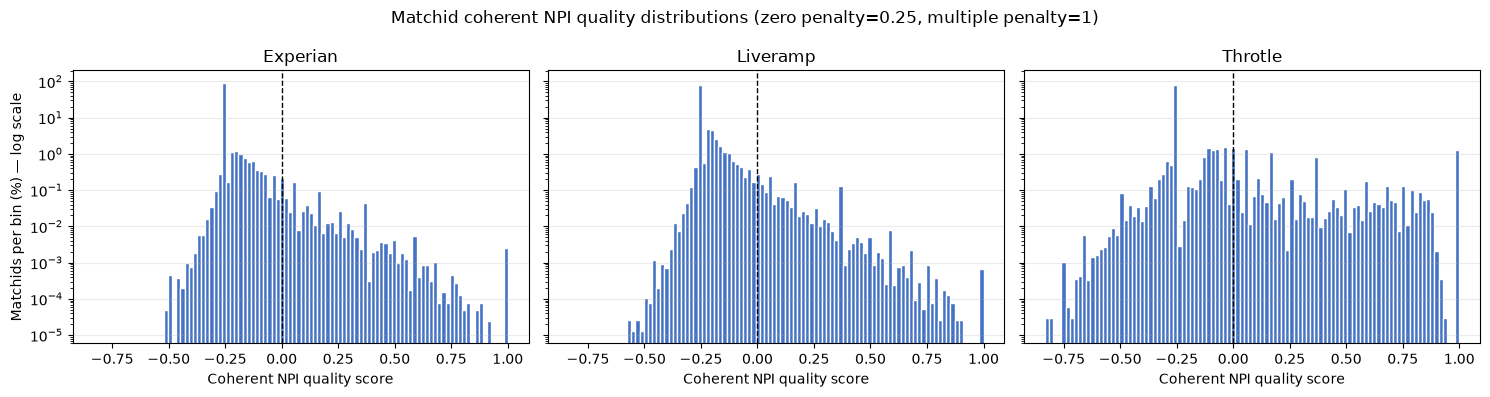

In [21]:
score_column = "npi_coherent_quality_score"
plot_data = matchid_npi_quality.dropna(subset=["vendor", score_column])
vendors = sorted(plot_data["vendor"].unique())
zero_penalty = plot_data["zero_npi_penalty"].iloc[0]
multiple_penalty = plot_data["multiple_npi_penalty"].iloc[0]
score_min = plot_data[score_column].min()
score_max = plot_data[score_column].max()
bins = np.linspace(score_min, score_max, 101)

fig, axes = plt.subplots(
    1,
    len(vendors),
    figsize=(5 * len(vendors), 4),
    sharex=True,
    sharey=True,
    squeeze=False,
)

for ax, vendor in zip(axes.flat, vendors):
    scores = plot_data.loc[
        plot_data["vendor"] == vendor, score_column
    ]
    weights = np.full(len(scores), 100 / len(scores))
    ax.hist(
        scores,
        bins=bins,
        weights=weights,
        color="#4472C4",
        edgecolor="white",
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yscale("log")
    ax.set_title(vendor.title())
    ax.set_xlabel("Coherent NPI quality score")
    ax.grid(axis="y", alpha=0.25)

axes[0, 0].set_ylabel("Matchids per bin (%) — log scale")
fig.suptitle(
    "Matchid coherent NPI quality distributions "
    f"(zero penalty={zero_penalty:g}, multiple penalty={multiple_penalty:g})"
)
fig.tight_layout()
plt.show()

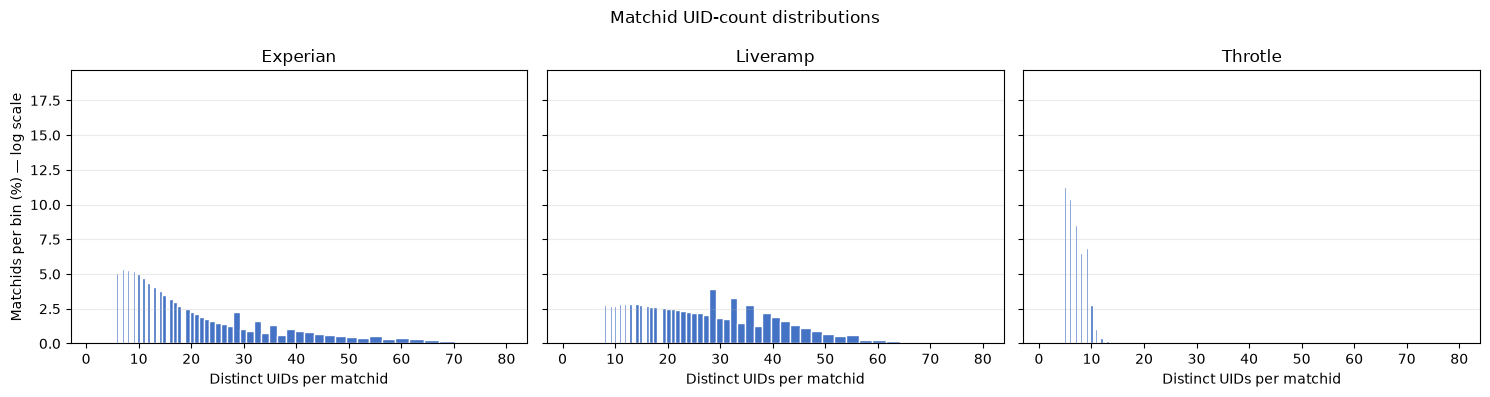

In [22]:
uid_plot_data = matchid_npi_quality.dropna(subset=["vendor", "n_uids"])
vendors = sorted(uid_plot_data["vendor"].unique())
uid_max = uid_plot_data["n_uids"].max()
uid_bins = np.geomspace(1, uid_max + 1, 101)

fig, axes = plt.subplots(
    1,
    len(vendors),
    figsize=(5 * len(vendors), 4),
    sharex=True,
    sharey=True,
    squeeze=False,
)

for ax, vendor in zip(axes.flat, vendors):
    uid_counts = uid_plot_data.loc[
        uid_plot_data["vendor"] == vendor, "n_uids"
    ]
    weights = np.full(len(uid_counts), 100 / len(uid_counts))
    ax.hist(
        uid_counts,
        bins=uid_bins,
        weights=weights,
        color="#4472C4",
        edgecolor="white",
    )
    ax.set_title(vendor.title())
    ax.set_xlabel("Distinct UIDs per matchid")
    ax.grid(axis="y", alpha=0.25)

axes[0, 0].set_ylabel("Matchids per bin (%) — log scale")
fig.suptitle("Matchid UID-count distributions")
fig.tight_layout()
plt.show()